# Signal Research: Momentum and Reversal

This notebook investigates whether recent cross-sectional cryptocurrency performance predicts subsequent hourly returns.

The analysis compares:

- cross-sectional momentum, where recent winners continue to outperform;
- cross-sectional reversal, where recent winners subsequently underperform;
- multiple formation horizons from 1 to 168 hours;
- signal strength and predictive consistency across time.

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# step 1: read my data

In [4]:
processed_data_dir = Path("data/processed")

data_path = (
    processed_data_dir
    / "crypto_10_assets_1h_clean.parquet"
)

df = pd.read_parquet(data_path)

df = (
    df
    .sort_values(["symbol", "open_time"])
    .reset_index(drop=True)
)

df.head()

,open_time,open,high,low,close,volume,quote_asset_volume,number_of_trades,taker_buy_base_volume,taker_buy_quote_volume,symbol
0,2023-01-01 00:00:00+00:00,0.2458,0.2459,0.2441,0.2445,4476440.1,1.096436e+06,1979,2325058.2,569457.21279,ADAUSDT
1,2023-01-01 01:00:00+00:00,0.2446,0.2455,0.2443,0.2452,2247531.8,5.498366e+05,1110,1176230.7,287778.97095,ADAUSDT
2,2023-01-01 02:00:00+00:00,0.2452,0.2462,0.2449,0.2456,1878723.3,4.616204e+05,923,993206.7,243976.96105,ADAUSDT
3,2023-01-01 03:00:00+00:00,0.2456,0.2458,0.2452,0.2454,2778149.2,6.818411e+05,1139,1332950.4,327156.00797,ADAUSDT
4,2023-01-01 04:00:00+00:00,0.2454,0.2455,0.2444,0.2446,1326482.4,3.247254e+05,807,574781.7,140711.28901,ADAUSDT


In [ ]:
# step 2: calculate 1 hour return

In [6]:
df["return_1h"] = (
    df.groupby("symbol")["close"]
    .pct_change()
)


In [ ]:
# step 3: build formation horizons

In [ ]:
formation_horizons = [
    1,
    3,
    6,
    12,
    24,
    72,
    168,
] #   Formation horizons:past 1, 3, 6, 12, 24, 72 and 168 hours

In [ ]:
# step 4 calculate momentum signals

In [10]:
for horizon in formation_horizons:

    df[f"signal_{horizon}h"] = (
        df.groupby("symbol")["close"]
        .pct_change(periods=horizon)
    )

In [ ]:
# step 5 calculate next hour return

In [12]:
df["future_return_1h"] = (
    df.groupby("symbol")["return_1h"]
    .shift(-1)
)

In [ ]:

# Step 6: rank cryptocurrencies cross-sectionally
# using their past 24-hour returns

In [18]:
for horizon in formation_horizons:

    df[f"rank_{horizon}h"] = (
        df.groupby("open_time")[f"signal_{horizon}h"]
        .rank(
            method="first",
            ascending=True,
        )
    ) # For each hour， rank the 10 cryptos by their 24-hour return from lowest to highest

In [ ]:
# step 7: check the ranking 

In [20]:
df[
    [
        "open_time",
        "symbol",
        "signal_24h",
        "rank_24h",
        "future_return_1h",
    ]
].dropna().head(20)

,open_time,symbol,signal_24h,rank_24h,future_return_1h
24,2023-01-02 00:00:00+00:00,ADAUSDT,0.017587,10.0,-0.004823
25,2023-01-02 01:00:00+00:00,ADAUSDT,0.009788,10.0,0.002423
26,2023-01-02 02:00:00+00:00,ADAUSDT,0.010586,9.0,0.006044
27,2023-01-02 03:00:00+00:00,ADAUSDT,0.017522,9.0,0.000000
28,2023-01-02 04:00:00+00:00,ADAUSDT,0.020850,10.0,0.000801
29,2023-01-02 05:00:00+00:00,ADAUSDT,0.022086,10.0,-0.000400
30,2023-01-02 06:00:00+00:00,ADAUSDT,0.021677,10.0,0.017214
31,2023-01-02 07:00:00+00:00,ADAUSDT,0.036297,7.0,0.000787
32,2023-01-02 08:00:00+00:00,ADAUSDT,0.040933,7.0,-0.001966
33,2023-01-02 09:00:00+00:00,ADAUSDT,0.035073,7.0,0.000394


## Cross-Sectional Information Coefficient

The Information Coefficient measures the cross-sectional relationship between each formation-period signal and the subsequent one-hour return.

A positive IC supports momentum, while a negative IC supports reversal.

In [25]:
# step 8 calculate each hour cross-sectional Information coefficient, if IC=1, momentum, if ic= -1, reversal

In [27]:
# Step 8: calculate hourly cross-sectional IC
# for each formation horizon

ic_results = []
ic_series_by_horizon = {}

for horizon in formation_horizons:

    signal_col = f"signal_{horizon}h"

    valid_data = df[
        [
            "open_time",
            signal_col,
            "future_return_1h",
        ]
    ].dropna()

    hourly_ic_values = []
    hourly_ic_times = []

    for open_time, group in valid_data.groupby("open_time"):

        # Correlation cannot be calculated when either
        # the signal or future returns are constant.
        if (
            group[signal_col].nunique() < 2
            or group["future_return_1h"].nunique() < 2
        ):
            continue

        ic = group[signal_col].corr(
            group["future_return_1h"],
            method="spearman",
        )

        if pd.notna(ic):
            hourly_ic_times.append(open_time)
            hourly_ic_values.append(ic)

    hourly_ic = pd.Series(
        hourly_ic_values,
        index=hourly_ic_times,
        name=f"ic_{horizon}h",
    )

    ic_series_by_horizon[horizon] = hourly_ic

    ic_results.append(
        {
            "horizon_hours": horizon,
            "mean_ic": hourly_ic.mean(),
            "ic_volatility": hourly_ic.std(),
            "positive_ic_ratio": (
                hourly_ic > 0
            ).mean(),
            "observations": len(hourly_ic),
        }
    )

ic_results_df = pd.DataFrame(ic_results)

ic_results_df

,horizon_hours,mean_ic,ic_volatility,positive_ic_ratio,observations
0,1,-0.042257,0.386484,0.455455,26299
1,3,-0.039901,0.388262,0.462088,26298
2,6,-0.034194,0.388065,0.466096,26295
3,12,-0.027114,0.388654,0.473924,26289
4,24,-0.022947,0.391788,0.474940,26277
5,72,-0.017021,0.390616,0.479736,26229
6,168,-0.010267,0.392084,0.488501,26133


In [ ]:
# formation horizon shows reversal, rather than momentum
#cryptos performed better in the past tend to underperform on average in the next hour;
#cryptos that performed worse tend to rebound more on average.
# ic_ volativity high, 0.39, mean is low, signal unreliable

## Information Coefficient Findings

The mean cross-sectional Information Coefficient is negative across all formation horizons, indicating that recent winners tend to underperform in the subsequent hour while recent losers tend to outperform.

The reversal effect is strongest at short horizons, with the one-hour signal producing the most negative mean IC. The magnitude of the IC becomes progressively smaller as the formation horizon increases, suggesting that predictive power weakens over longer lookback periods.

The high dispersion of hourly IC values indicates that the relationship is unstable over time and should be evaluated further using portfolio-level backtests, transaction costs and robustness tests.

In [ ]:
# plot mean ic

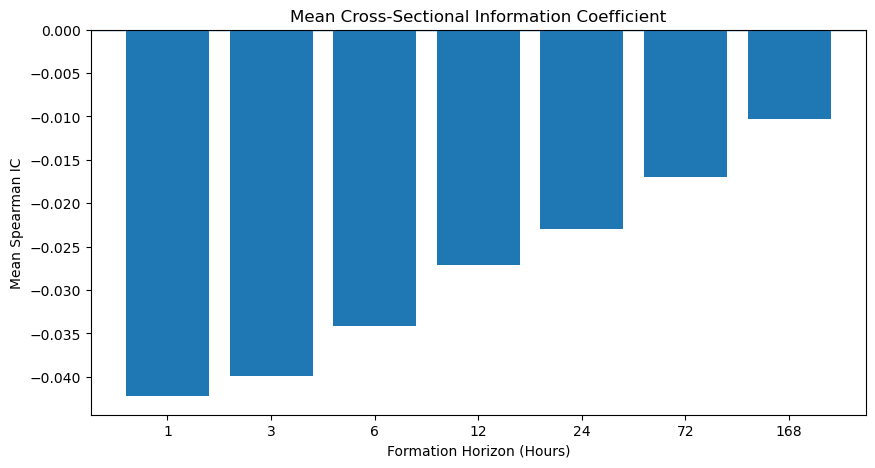

In [30]:
plt.figure(figsize=(10, 5))

plt.bar(
    ic_results_df["horizon_hours"].astype(str),
    ic_results_df["mean_ic"],
)

plt.axhline(
    0,
    linewidth=1,
)

plt.title(
    "Mean Cross-Sectional Information Coefficient"
)

plt.xlabel("Formation Horizon (Hours)")
plt.ylabel("Mean Spearman IC")

plt.show()

In [ ]:
# What is the average return in the next hour for each past 1-hour performance rank?

In [32]:
rank_return_1h = (
    df.groupby("rank_1h")["future_return_1h"]
    .mean()
    .reset_index()
)

rank_return_1h

,rank_1h,future_return_1h
0,1.0,0.000218
1,2.0,0.000127
2,3.0,0.000038
3,4.0,0.000132
4,5.0,0.000065
5,6.0,0.000058
6,7.0,-0.000016
7,8.0,0.000058
8,9.0,-0.000018
9,10.0,0.000077


In [ ]:
# Key finding:
# The bottom-ranked coins (worst past 1-hour performance) 
# averaged a positive return of ~0.0218% in the subsequent hour.

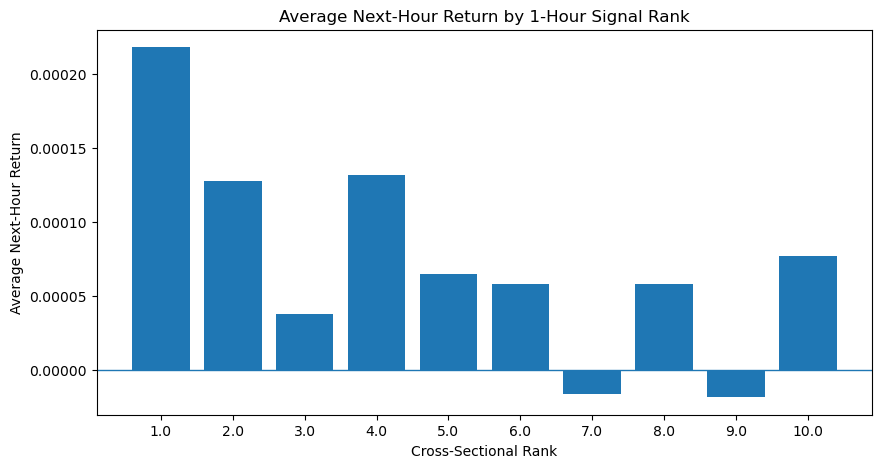

In [34]:
plt.figure(figsize=(10, 5))

plt.bar(
    rank_return_1h["rank_1h"].astype(str),
    rank_return_1h["future_return_1h"],
)

plt.axhline(
    0,
    linewidth=1,
)

plt.title(
    "Average Next-Hour Return by 1-Hour Signal Rank"
)

plt.xlabel("Cross-Sectional Rank")
plt.ylabel("Average Next-Hour Return")

plt.show()

## Next-Hour Returns by Signal Rank

The chart shows the average subsequent one-hour return for each cross-sectional signal rank. Rank 1 represents the worst performer over the previous hour, while rank 10 represents the best performer.

The strongest average next-hour return is observed for rank 1, supporting short-term reversal. However, returns are not monotonic across all ranks, indicating that the relationship is noisy and requires portfolio-level validation.


In [36]:
spread_results = []

for horizon in formation_horizons:

    rank_col = f"rank_{horizon}h"

    valid_data = df[
        [
            "open_time",
            rank_col,
            "future_return_1h",
        ]
    ].dropna()

    bottom_returns = (
        valid_data[
            valid_data[rank_col] <= 3
        ]
        .groupby("open_time")["future_return_1h"]
        .mean()
    )

    top_returns = (
        valid_data[
            valid_data[rank_col] >= 8
        ]
        .groupby("open_time")["future_return_1h"]
        .mean()
    )

    reversal_spread = (
        bottom_returns - top_returns
    ).dropna()

    spread_results.append(
        {
            "horizon_hours": horizon,
            "mean_reversal_spread": (
                reversal_spread.mean()
            ),
            "spread_volatility": (
                reversal_spread.std()
            ),
            "positive_spread_ratio": (
                reversal_spread > 0
            ).mean(),
            "observations": len(
                reversal_spread
            ),
        }
    )

spread_results_df = pd.DataFrame(
    spread_results
)

spread_results_df

,horizon_hours,mean_reversal_spread,spread_volatility,positive_spread_ratio,observations
0,1,0.000089,0.005112,0.532717,26301
1,3,0.000019,0.005133,0.522377,26299
2,6,-0.000008,0.005149,0.517417,26296
3,12,-0.000047,0.005179,0.510993,26290
4,24,-0.000077,0.005216,0.512254,26278
5,72,-0.000058,0.005214,0.507396,26230
6,168,-0.000069,0.005195,0.505587,26134


In [43]:
# Reversal Spread=Bottom 3 Return−Top 3 Return
# If the result is positive, it supports reversal; if negative, it suggests 
#the top 3 are actually stronger, indicating momentum.

## Reversal Spread Findings

The one-hour and three-hour signals show some evidence of reversal, with the strongest result at the one-hour horizon.

However, the average spread is small and unstable. Since the gross return is much lower than the assumed transaction cost, the strategy may not be profitable after costs.

In [38]:
signal_results_dir = Path(
    "results/signal_research"
)

signal_results_dir.mkdir(
    parents=True,
    exist_ok=True,
)

ic_results_df.to_csv(
    signal_results_dir
    / "information_coefficient_summary.csv",
    index=False,
)

spread_results_df.to_csv(
    signal_results_dir
    / "reversal_spread_summary.csv",
    index=False,
)

print("Signal research results saved.")

Signal research results saved.


## Signal Research Conclusion

Cross-sectional Information Coefficients are negative across all tested formation horizons, providing preliminary evidence of short-term reversal.

The reversal relationship is strongest at the shortest formation horizons and weakens as the lookback window increases. Portfolio-level backtesting is required to determine whether the signal remains economically meaningful after turnover and transaction costs.